<a href="https://colab.research.google.com/github/l3anxna/what-you-eat-decides-your-grade/blob/banana-feature-engineering/EDA_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import userdata

# Retrieve credentials
token = userdata.get('GITHUB_TOKEN')
username = "l3anxna" # YOUR GITHUB NAME
repo_name = "what-you-eat-decides-your-grade"

# Configure git URL
repo_url = f"https://{token}@github.com/{username}/{repo_name}.git"

# Clone if it doesn't exist, otherwise pull latest
if not os.path.exists(repo_name):
    !git clone {repo_url}
    %cd {repo_name}
else:
    %cd {repo_name}
    !git pull


/content/what-you-eat-decides-your-grade
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 3 (delta 2), reused 3 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 370 bytes | 370.00 KiB/s, done.
From https://github.com/l3anxna/what-you-eat-decides-your-grade
   8c76877..9f7f01a  taco-docker -> origin/taco-docker
Already up to date.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

plt.style.use("ggplot")

## 1. Load Dataset

In [3]:
df = pd.read_csv("/content/what-you-eat-decides-your-grade/Food Choices.csv")

print("=" * 50)
print("Dataset Shape:", df.shape)
print("=" * 50)

df.head()

Dataset Shape: (125, 61)


,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,...,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
0,2.4,2,1,430,NaN,315.0,1,none,we dont have comfort,9.0,...,1.0,1.0,1,1165.0,345,car racing,5,1,1315,187
1,3.654,1,1,610,3.0,420.0,2,"chocolate, chips, ice cream","Stress, bored, anger",1.0,...,1.0,1.0,2,725.0,690,Basketball,4,2,900,155
2,3.3,1,1,720,4.0,420.0,2,"frozen yogurt, pizza, fast food","stress, sadness",1.0,...,1.0,2.0,5,1165.0,500,none,5,1,900,I'm not answering this.
3,3.2,1,1,430,3.0,420.0,2,"Pizza, Mac and cheese, ice cream",Boredom,2.0,...,1.0,2.0,5,725.0,690,NaN,3,1,1315,"Not sure, 240"
4,3.5,1,1,720,2.0,420.0,2,"Ice cream, chocolate, chips","Stress, boredom, cravings",1.0,...,1.0,1.0,4,940.0,500,Softball,4,2,760,190


## 2. Dataset Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GPA                           123 non-null    object 
 1   Gender                        125 non-null    int64  
 2   breakfast                     125 non-null    int64  
 3   calories_chicken              125 non-null    int64  
 4   calories_day                  106 non-null    float64
 5   calories_scone                124 non-null    float64
 6   coffee                        125 non-null    int64  
 7   comfort_food                  124 non-null    object 
 8   comfort_food_reasons          123 non-null    object 
 9   comfort_food_reasons_coded    106 non-null    float64
 10  cook                          122 non-null    float64
 11  comfort_food_reasons_coded.1  125 non-null    int64  
 12  cuisine                       108 non-null    float64
 13  diet_

In [5]:
df.describe(include="all")

,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,...,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
count,123,125.000000,125.000000,125.000000,106.000000,124.000000,125.00000,124,123,106.000000,...,124.000000,123.000000,125.000000,124.000000,125.000000,99,125.000000,125.000000,125.000000,123
unique,38,NaN,NaN,NaN,NaN,NaN,NaN,124,106,NaN,...,NaN,NaN,NaN,NaN,NaN,66,NaN,NaN,NaN,47
top,3.5,NaN,NaN,NaN,NaN,NaN,NaN,none,boredom,NaN,...,NaN,NaN,NaN,NaN,NaN,none,NaN,NaN,NaN,135
freq,13,NaN,NaN,NaN,NaN,NaN,NaN,1,7,NaN,...,NaN,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,8
mean,NaN,1.392000,1.112000,577.320000,3.028302,505.241935,1.75200,NaN,NaN,2.698113,...,1.217742,1.390244,3.336000,947.580645,555.040000,NaN,4.008000,1.512000,1073.400000,NaN
std,NaN,0.490161,0.316636,131.214156,0.639308,230.840506,0.43359,NaN,NaN,1.972042,...,0.414385,0.489800,1.436528,202.090179,152.370379,NaN,1.081337,0.501867,248.667092,NaN
min,NaN,1.000000,1.000000,265.000000,2.000000,315.000000,1.00000,NaN,NaN,1.000000,...,1.000000,1.000000,1.000000,580.000000,345.000000,NaN,1.000000,1.000000,575.000000,NaN
25%,NaN,1.000000,1.000000,430.000000,3.000000,420.000000,2.00000,NaN,NaN,2.000000,...,1.000000,1.000000,2.000000,725.000000,500.000000,NaN,3.000000,1.000000,900.000000,NaN
50%,NaN,1.000000,1.000000,610.000000,3.000000,420.000000,2.00000,NaN,NaN,2.000000,...,1.000000,1.000000,3.000000,940.000000,500.000000,NaN,4.000000,2.000000,900.000000,NaN
75%,NaN,2.000000,1.000000,720.000000,3.000000,420.000000,2.00000,NaN,NaN,3.000000,...,1.000000,2.000000,5.000000,1165.000000,690.000000,NaN,5.000000,2.000000,1315.000000,NaN


## 3. Missing Value Analysis

In [6]:
missing_find = df.isnull().sum().sort_values(ascending=False)
missing = missing_find[missing_find > 0]

missing

,0
type_sports,26
comfort_food_reasons_coded,19
calories_day,19
cuisine,17
exercise,13
employment,9
eating_changes,3
cook,3
father_profession,3
meals_dinner_friend,3


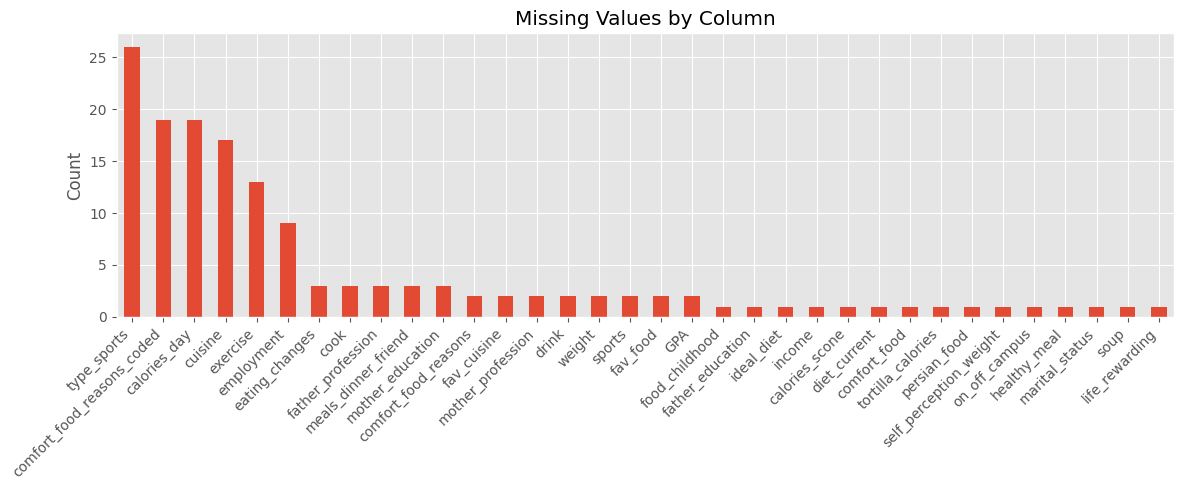

In [7]:
plt.figure(figsize=(12,5))

missing.plot(kind="bar")

plt.title("Missing Values by Column")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 4. Duplicate Rows

In [8]:
duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


## 5. Data Cleaning

In [9]:
df["GPA"] = pd.to_numeric(df["GPA"], errors="coerce")
df["weight"] = pd.to_numeric(df["weight"], errors="coerce")

## 6. Numerical Features

In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns

print(numeric_cols)

df[numeric_cols].describe().T

Index(['GPA', 'Gender', 'breakfast', 'calories_chicken', 'calories_day',
       'calories_scone', 'coffee', 'comfort_food_reasons_coded', 'cook',
       'comfort_food_reasons_coded.1', 'cuisine', 'diet_current_coded',
       'drink', 'eating_changes_coded', 'eating_changes_coded1', 'eating_out',
       'employment', 'ethnic_food', 'exercise', 'father_education',
       'fav_cuisine_coded', 'fav_food', 'fries', 'fruit_day', 'grade_level',
       'greek_food', 'healthy_feeling', 'ideal_diet_coded', 'income',
       'indian_food', 'italian_food', 'life_rewarding', 'marital_status',
       'mother_education', 'nutritional_check', 'on_off_campus',
       'parents_cook', 'pay_meal_out', 'persian_food',
       'self_perception_weight', 'soup', 'sports', 'thai_food',
       'tortilla_calories', 'turkey_calories', 'veggies_day', 'vitamins',
       'waffle_calories', 'weight'],
      dtype='object')


,count,mean,std,min,25%,50%,75%,max
GPA,120.0,3.415558,0.390139,2.2,3.2,3.5,3.7,4.0
Gender,125.0,1.392000,0.490161,1.0,1.0,1.0,2.0,2.0
breakfast,125.0,1.112000,0.316636,1.0,1.0,1.0,1.0,2.0
calories_chicken,125.0,577.320000,131.214156,265.0,430.0,610.0,720.0,720.0
calories_day,106.0,3.028302,0.639308,2.0,3.0,3.0,3.0,4.0
calories_scone,124.0,505.241935,230.840506,315.0,420.0,420.0,420.0,980.0
coffee,125.0,1.752000,0.433590,1.0,2.0,2.0,2.0,2.0
comfort_food_reasons_coded,106.0,2.698113,1.972042,1.0,2.0,2.0,3.0,9.0
cook,122.0,2.786885,1.038351,1.0,2.0,3.0,3.0,5.0
comfort_food_reasons_coded.1,125.0,2.688000,1.910987,1.0,2.0,2.0,3.0,9.0


## 7. Correlation Matrix

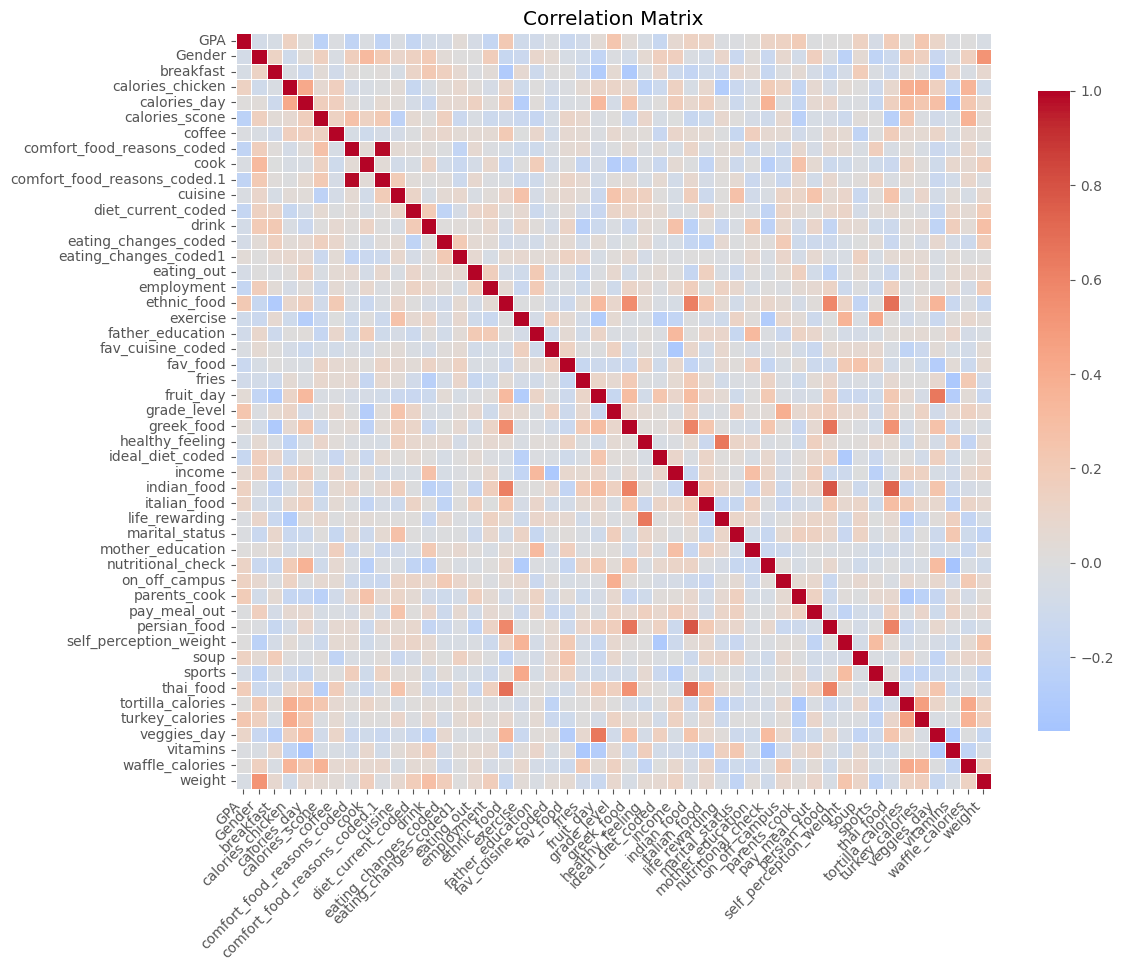

In [11]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)

plt.title("Correlation Matrix")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

## 8. Categorical Variables

In [12]:
cat_cols = df.select_dtypes(include="object").columns

cat_cols

Index(['comfort_food', 'comfort_food_reasons', 'diet_current',
       'eating_changes', 'father_profession', 'fav_cuisine', 'food_childhood',
       'healthy_meal', 'ideal_diet', 'meals_dinner_friend',
       'mother_profession', 'type_sports'],
      dtype='object')

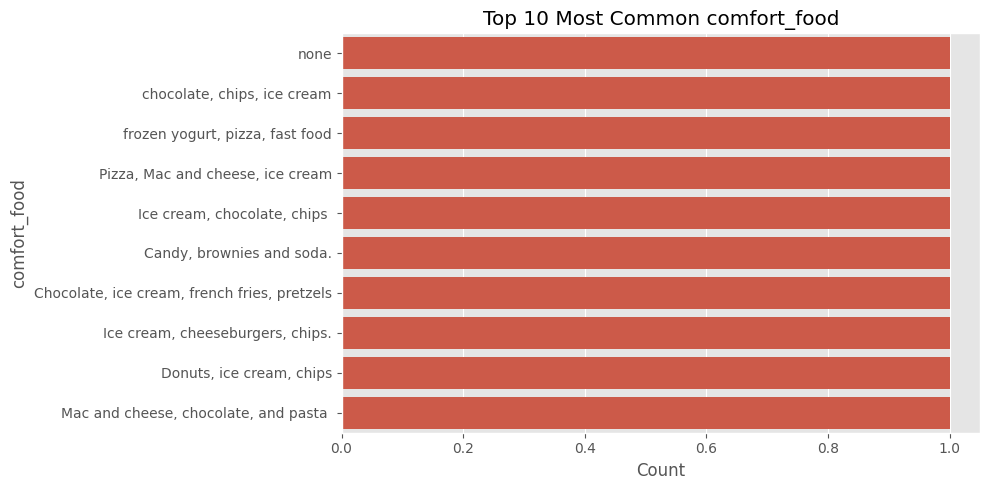

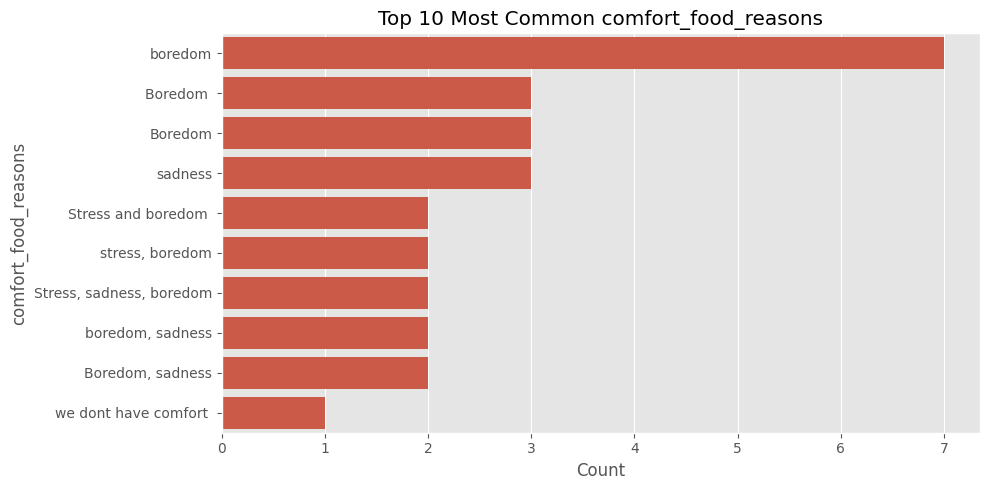

/tmp/ipykernel_8706/1054470264.py:37: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


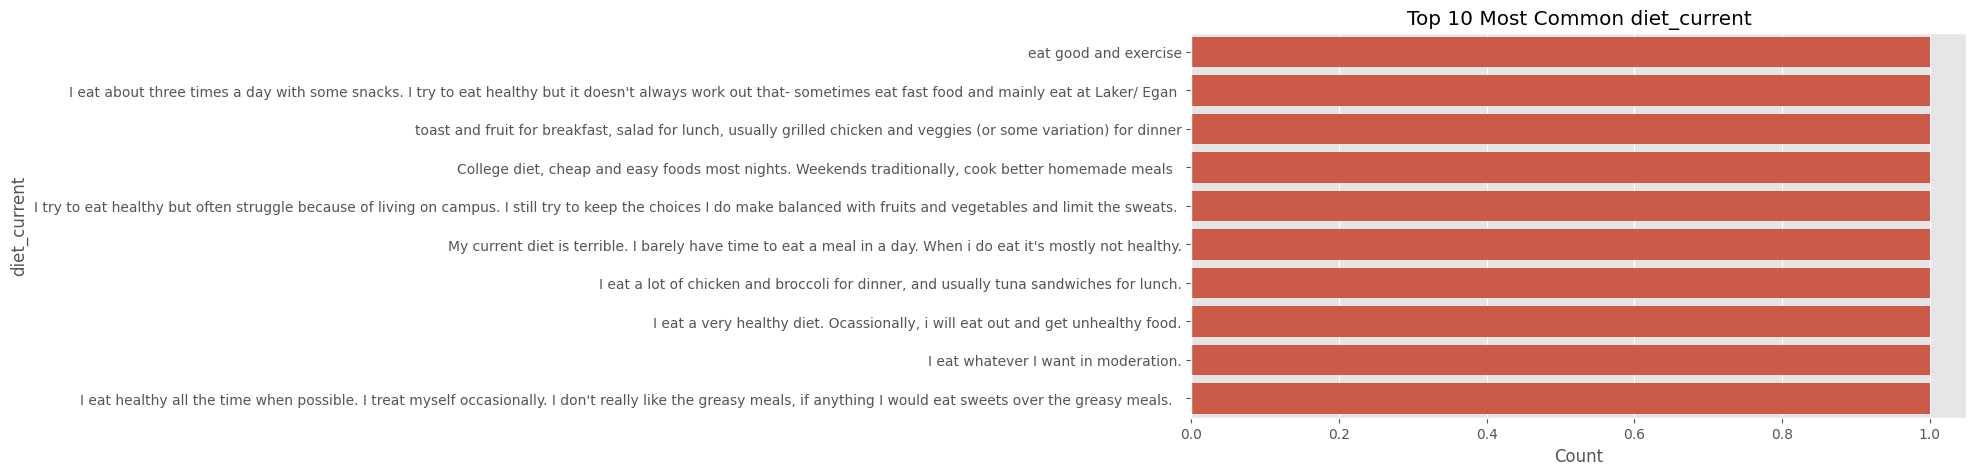

/tmp/ipykernel_8706/1054470264.py:37: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


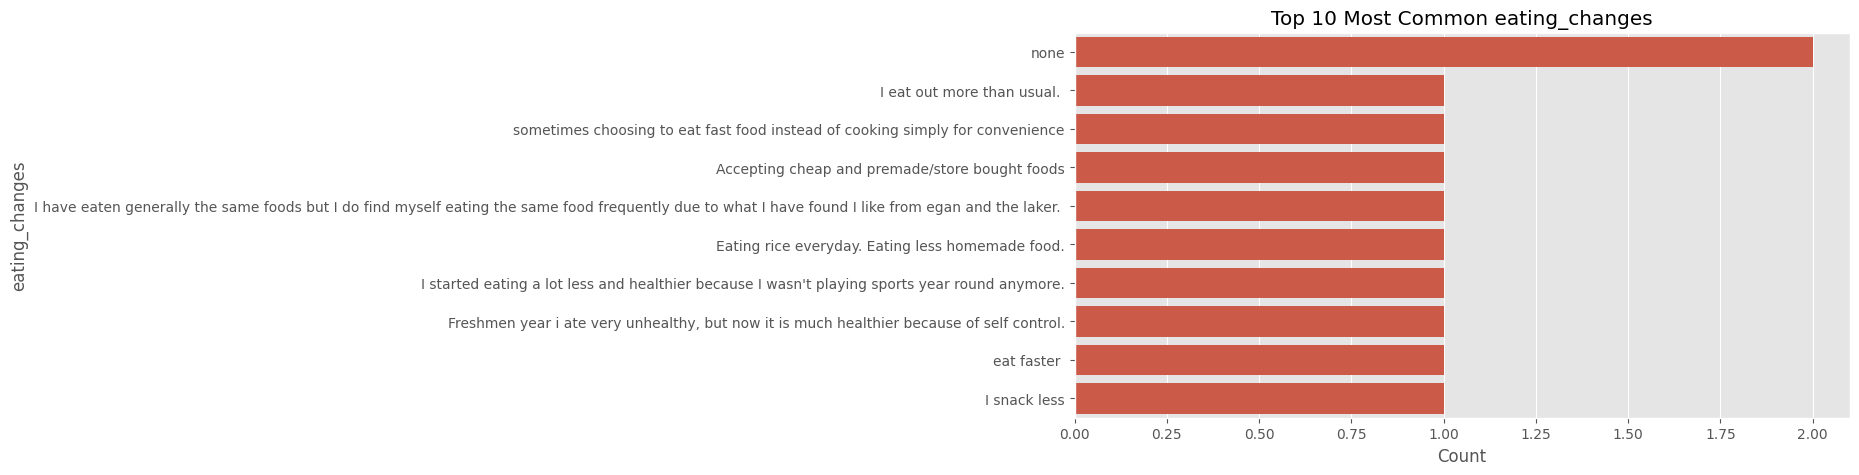

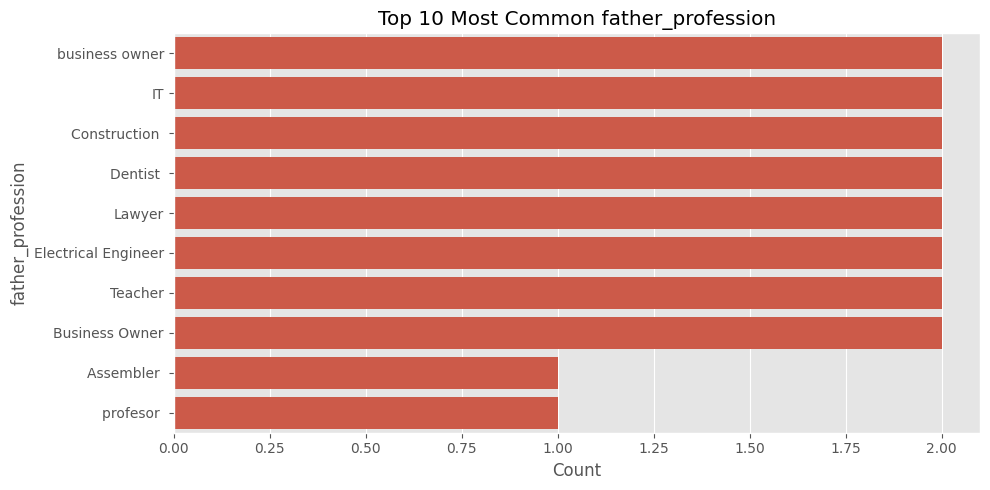

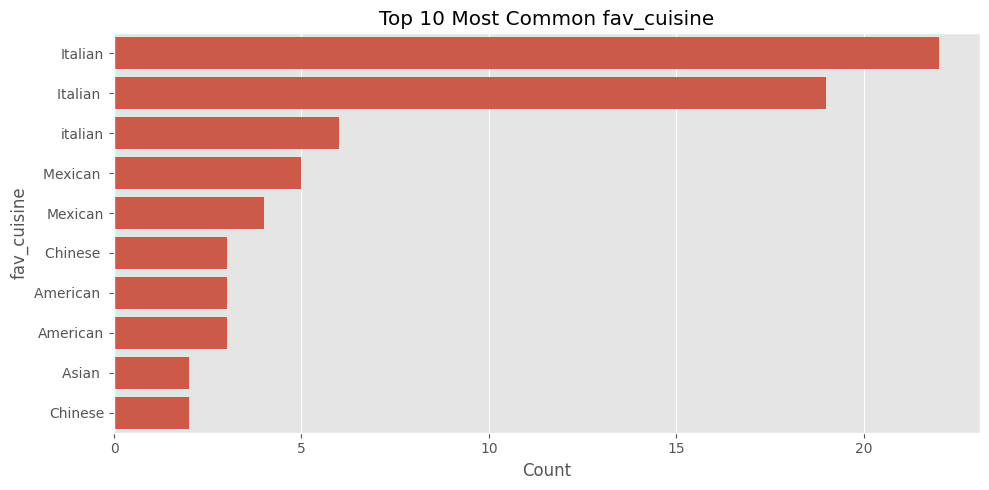

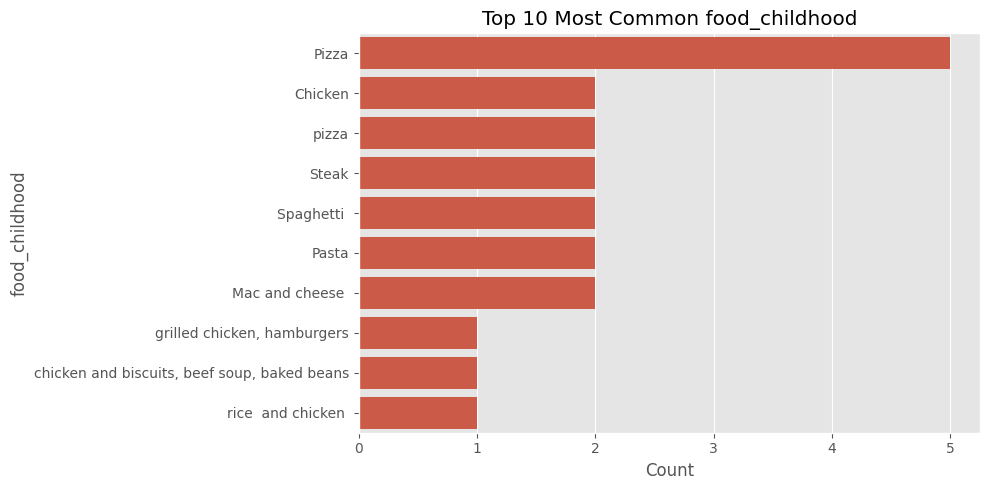

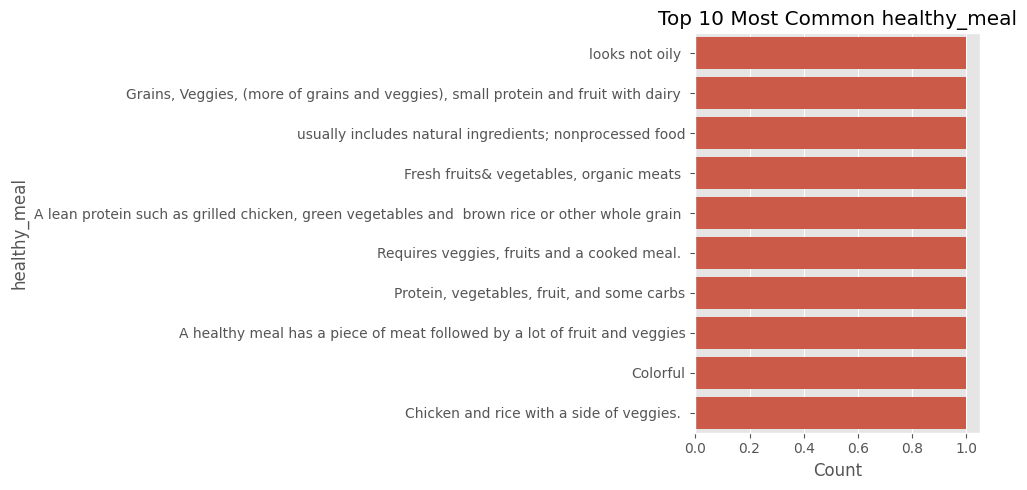

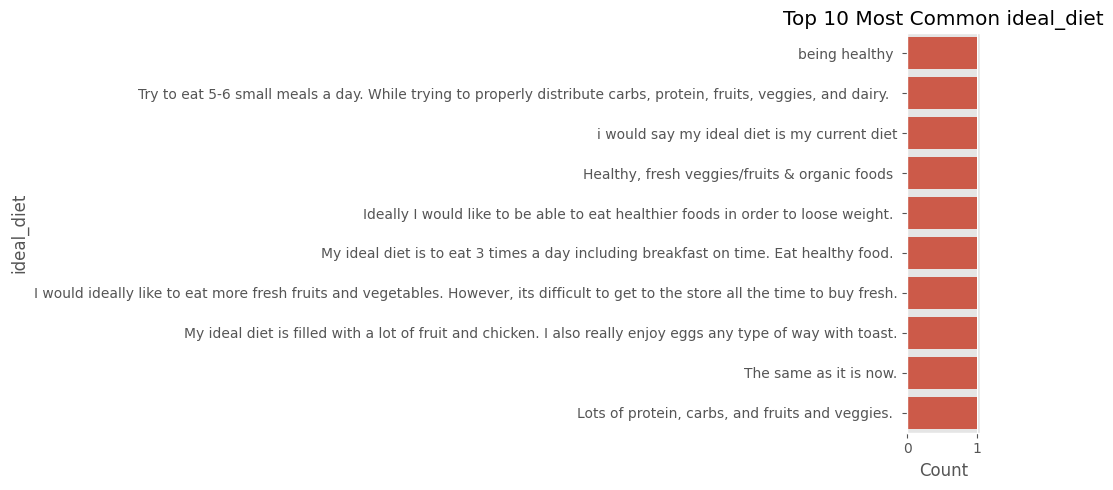

) missing from font(s) DejaVu Sans.
  plt.tight_layout()
) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


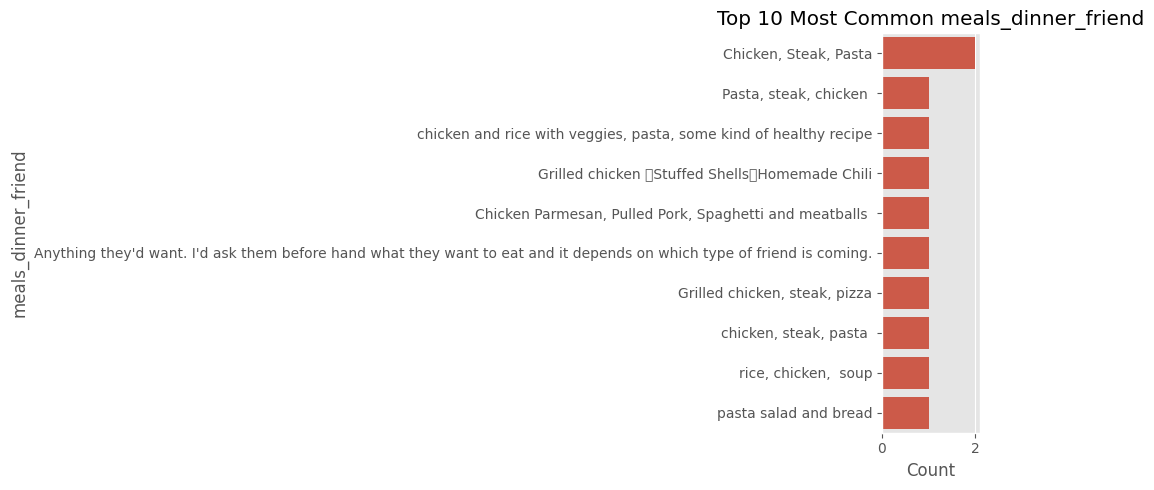

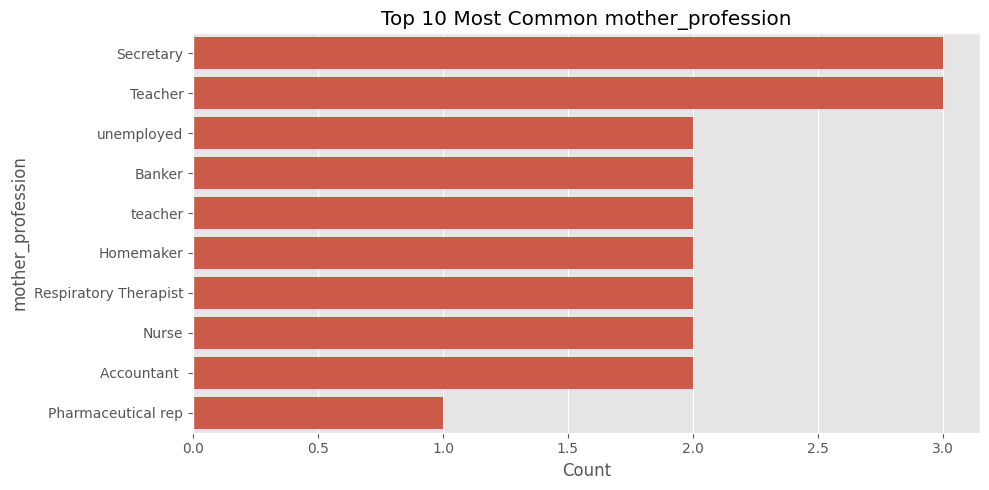

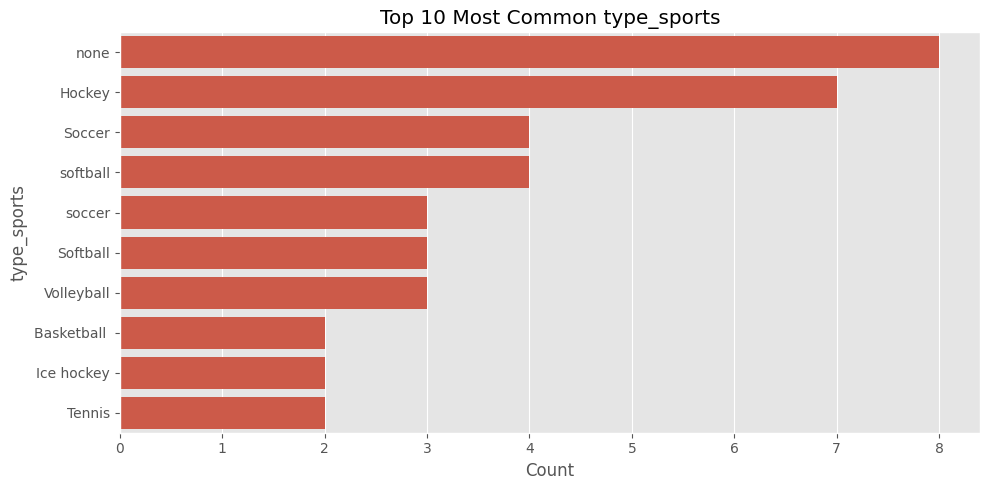

In [13]:
categorical_features = [
    "comfort_food",
    "comfort_food_reasons",
    "diet_current",
    "eating_changes",
    "father_profession",
    "fav_cuisine",
    "food_childhood",
    "healthy_meal",
    "ideal_diet",
    "meals_dinner_friend",
    "mother_profession",
    "type_sports",
]

top_n = 10

for col in categorical_features:

    if col not in df.columns:
        continue

    counts = df[col].value_counts().head(top_n)

    plt.figure(figsize=(10,5))

    sns.barplot(
        x=counts.values,
        y=counts.index
    )

    plt.title(f"Top {top_n} Most Common {col}")

    plt.xlabel("Count")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

## Clean categorical data

In [14]:
def normalize_text(text):
    if pd.isna(text):
        return text

    text = str(text).lower()
    text = text.strip()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)

    return text

object_cols = df.select_dtypes(include="object").columns

for col in object_cols:
    df[col] = df[col].apply(normalize_text)

In [15]:
def clean_comfort_reason(text):

    if pd.isna(text):
        return text

    if "bored" in text:
        return "boredom"

    if "stress" in text:
        return "stress"

    if "sad" in text:
        return "sadness"

    if "happy" in text:
        return "happiness"

    if "depress" in text:
        return "depression"

    return text

df["comfort_food_reasons"] = df["comfort_food_reasons"].apply(clean_comfort_reason)

In [16]:
for col in object_cols:
    print(f"{col:30} {df[col].nunique()} unique values")

comfort_food                   124 unique values
comfort_food_reasons           18 unique values
diet_current                   124 unique values
eating_changes                 121 unique values
father_profession              101 unique values
fav_cuisine                    48 unique values
food_childhood                 108 unique values
healthy_meal                   123 unique values
ideal_diet                     124 unique values
meals_dinner_friend            115 unique values
mother_profession              104 unique values
type_sports                    47 unique values


In [18]:
for col in object_cols:

    print("=" * 60)
    print(col)

    print(df[col].value_counts().head(20))

comfort_food
comfort_food
none                                                       1
chocolate chips ice cream                                  1
frozen yogurt pizza fast food                              1
pizza mac and cheese ice cream                             1
ice cream chocolate chips                                  1
candy brownies and soda                                    1
chocolate ice cream french fries pretzels                  1
ice cream cheeseburgers chips                              1
donuts ice cream chips                                     1
mac and cheese chocolate and pasta                         1
pasta grandma homemade chocolate cake anything homemade    1
chocolate pasta soup chips popcorn                         1
cookies popcorn and chips                                  1
ice cream cake chocolate                                   1
pizza fruit spaghetti chicken and potatoes                 1
cookies donuts candy bars                                  

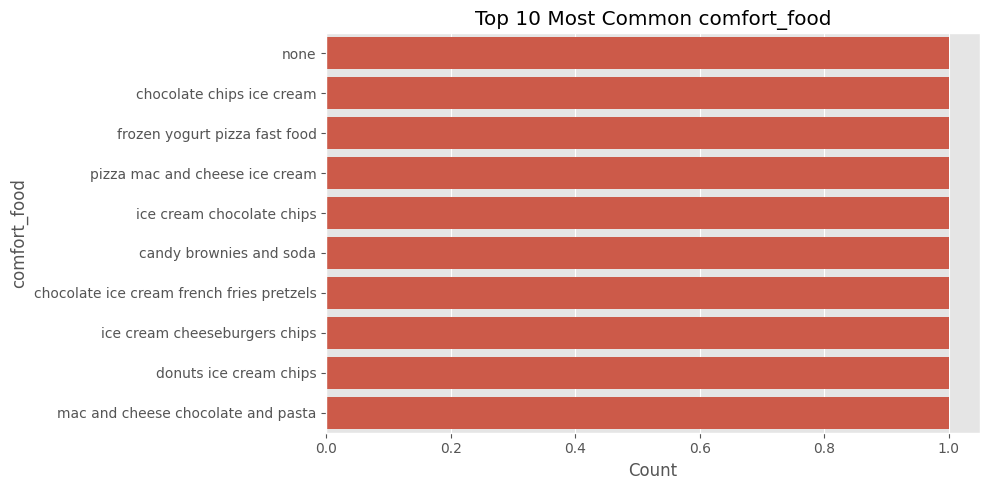

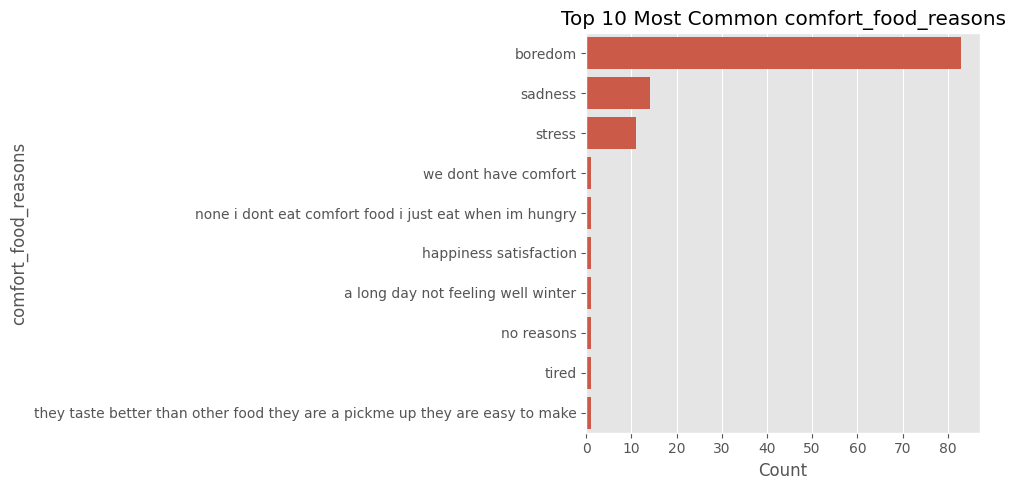

/tmp/ipykernel_8706/2872941165.py:22: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


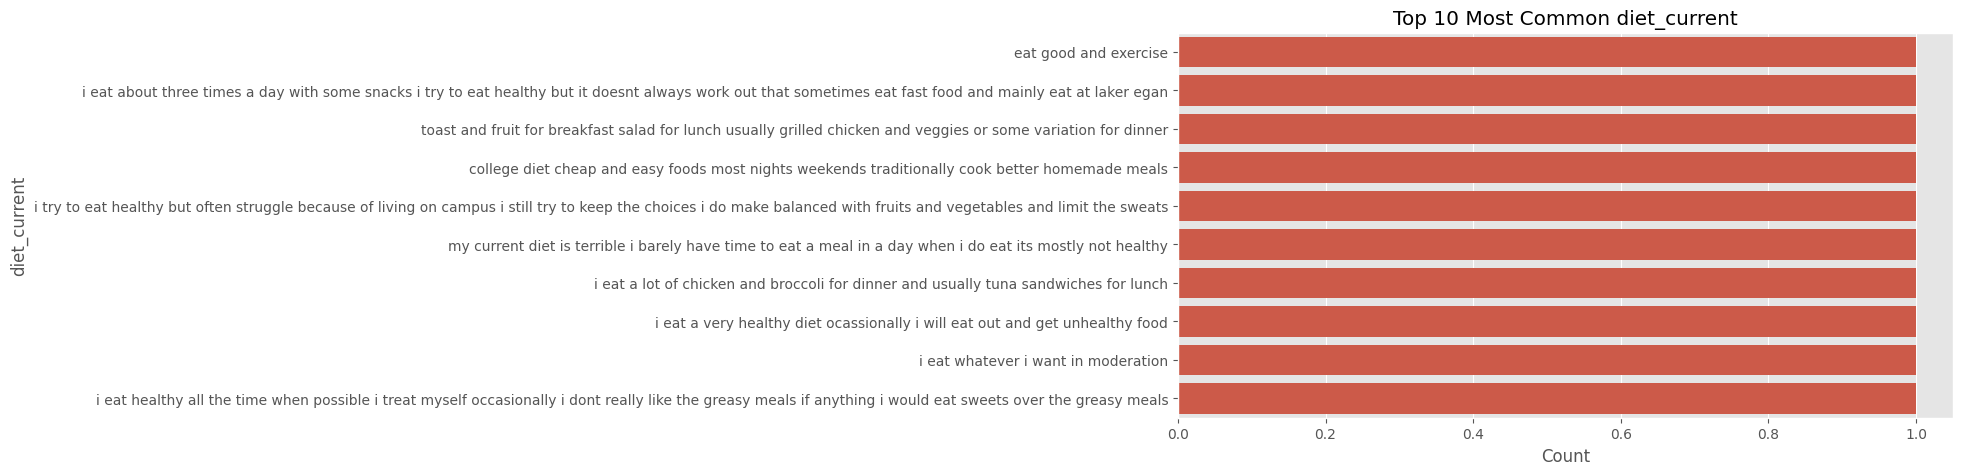

/tmp/ipykernel_8706/2872941165.py:22: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


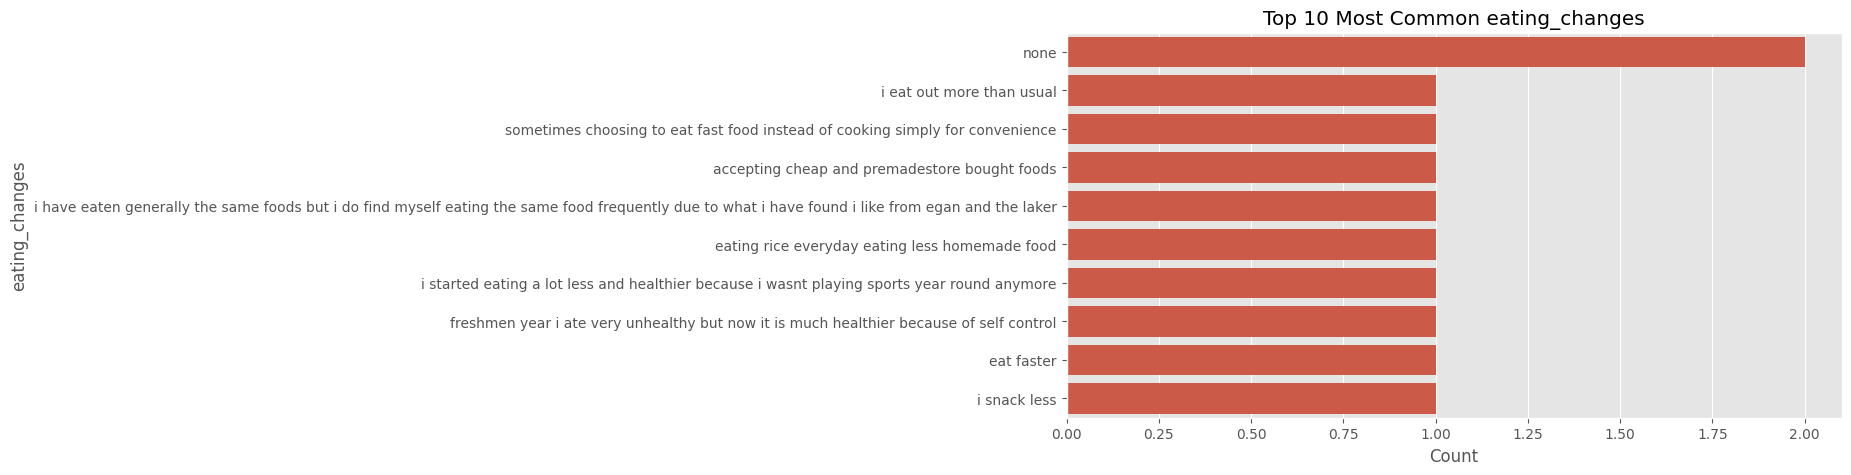

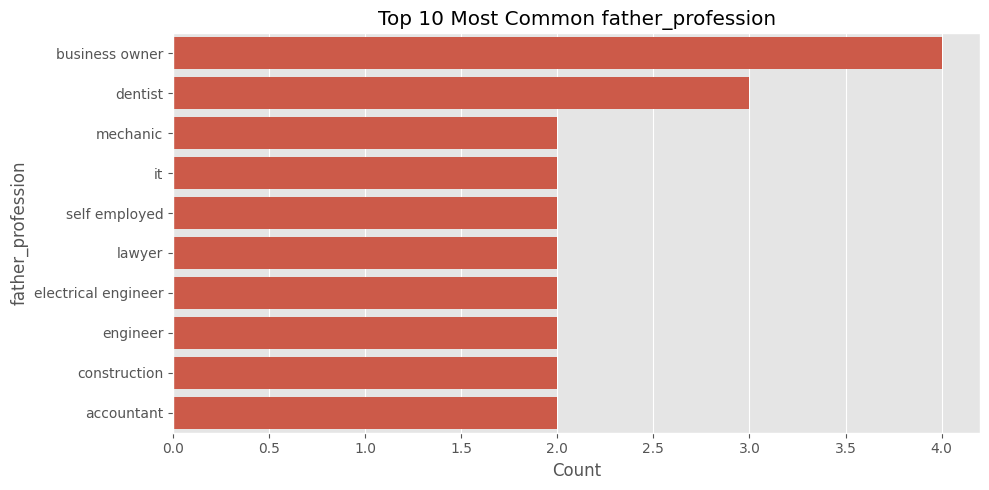

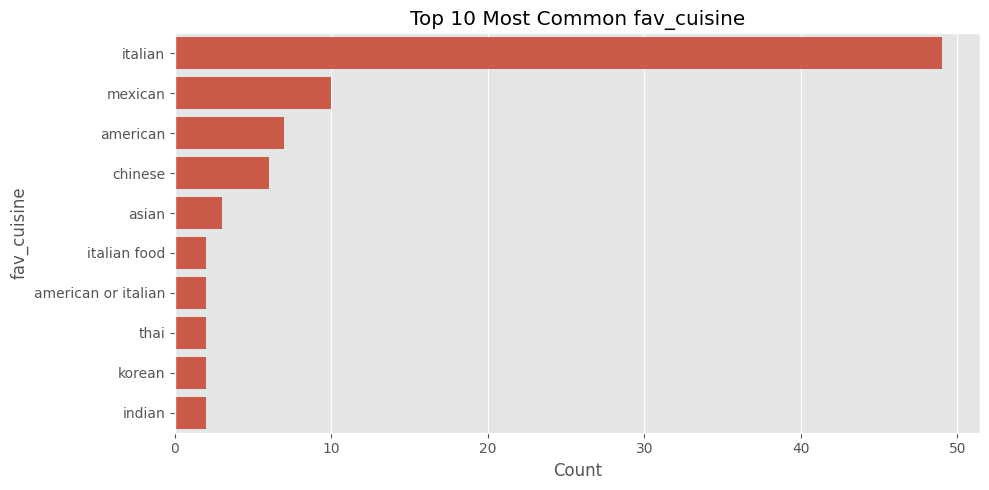

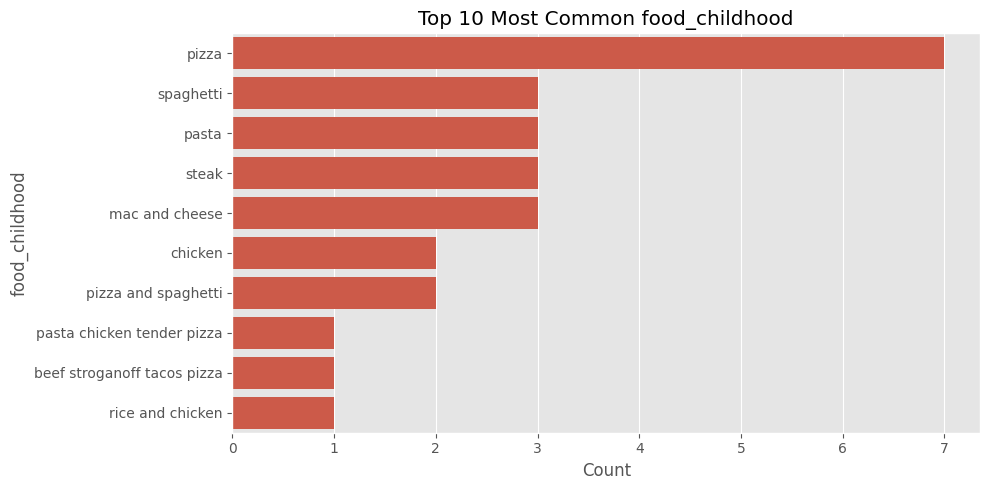

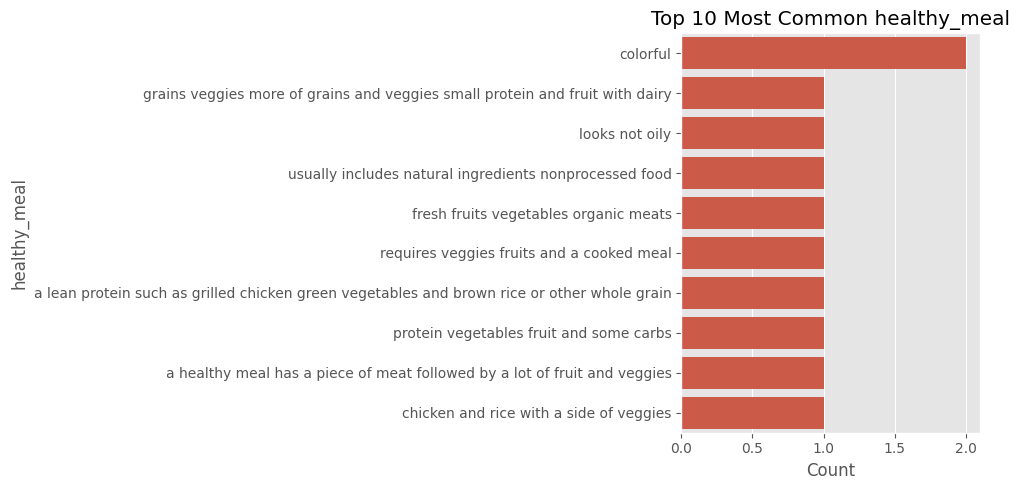

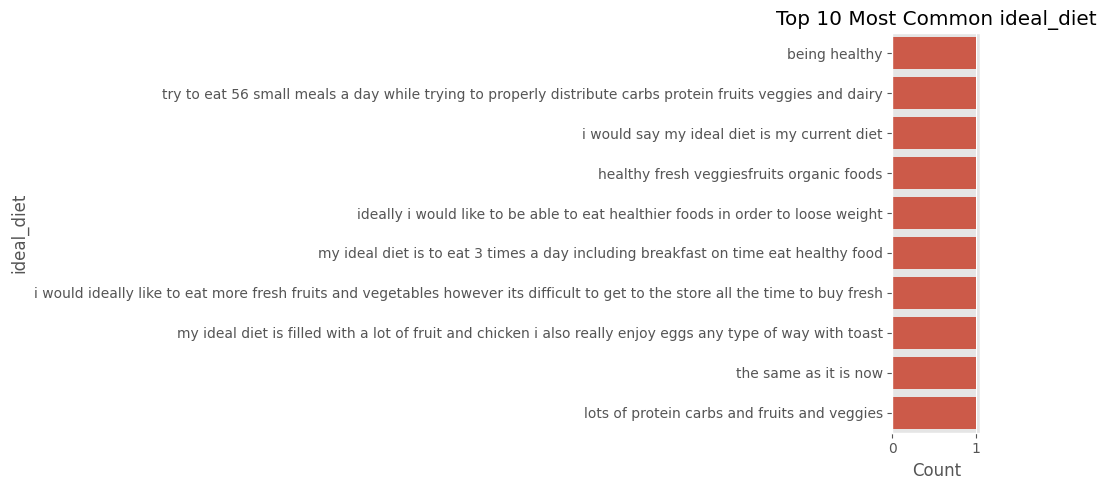

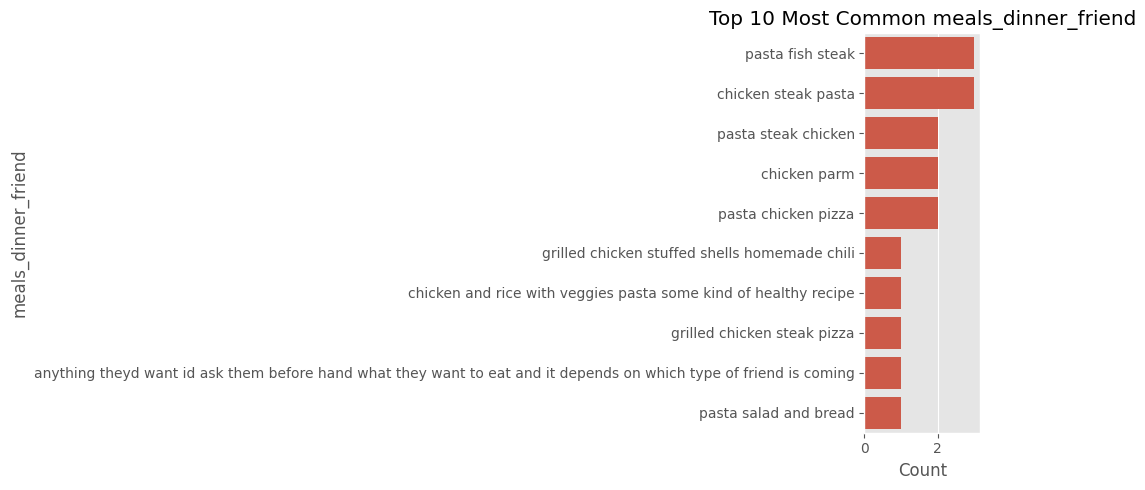

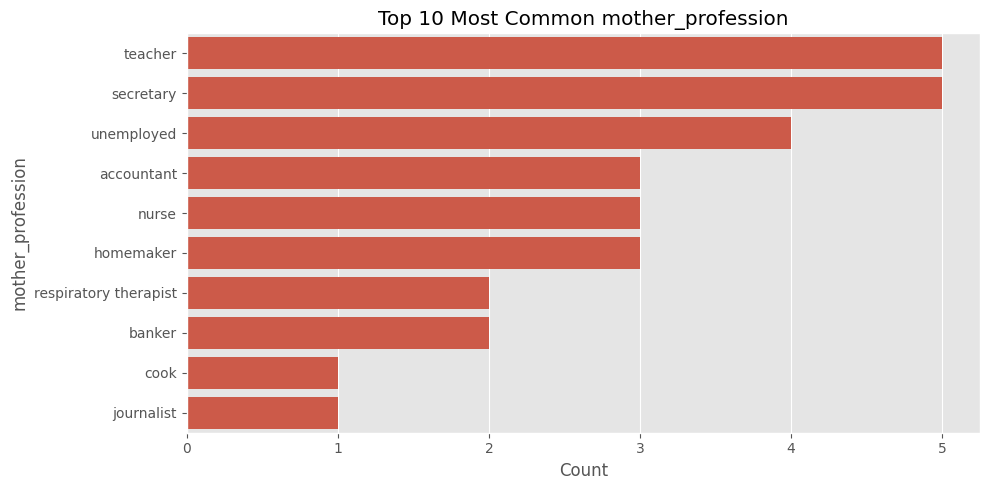

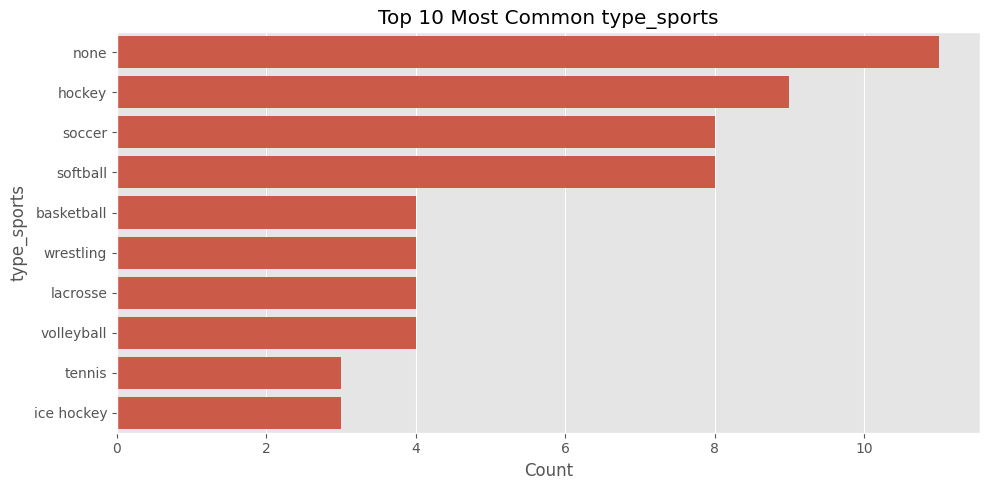

In [19]:
top_n_clean = 10

for col in object_cols:

    if col not in df.columns:
        continue

    counts = df[col].value_counts().head(top_n)

    plt.figure(figsize=(10,5))

    sns.barplot(
        x=counts.values,
        y=counts.index
    )

    plt.title(f"Top {top_n} Most Common {col}")

    plt.xlabel("Count")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

## 9. Correlation with GPA

In [20]:
corr_gpa = df[numeric_cols].corr()["GPA"].sort_values(ascending=False)

corr_gpa

,GPA
GPA,1.000000
grade_level,0.237820
turkey_calories,0.231468
ethnic_food,0.215631
parents_cook,0.193205
thai_food,0.187303
on_off_campus,0.137721
indian_food,0.135502
calories_chicken,0.134665
soup,0.131949


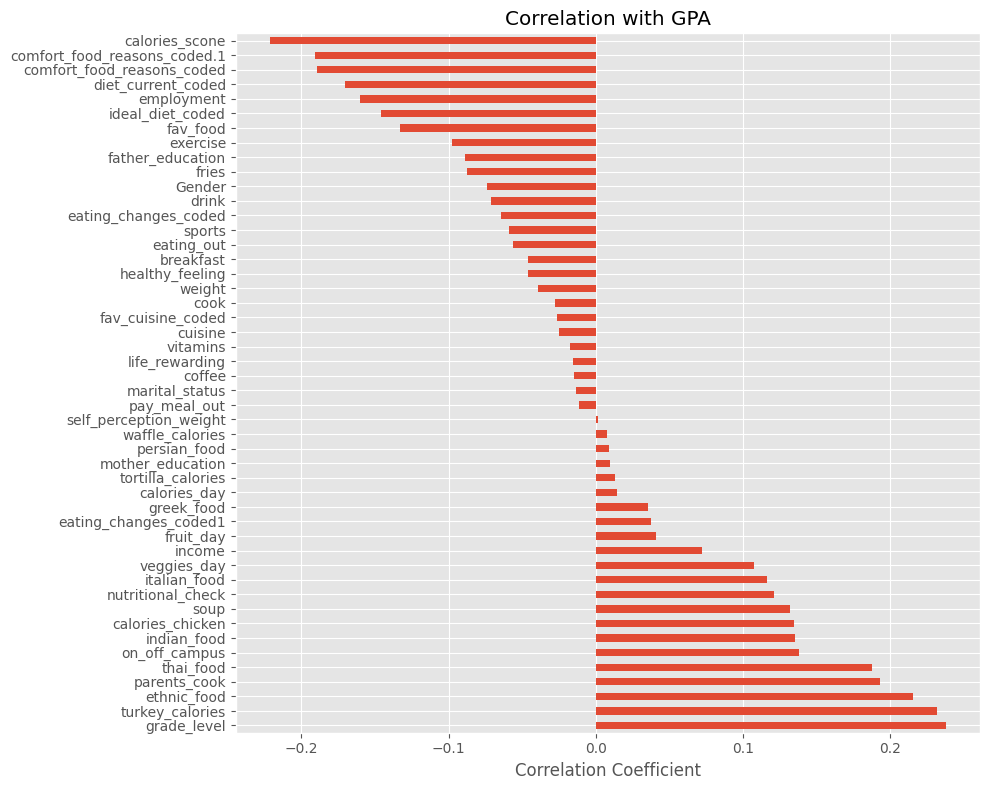

In [21]:
plt.figure(figsize=(10,8))

corr_gpa.drop("GPA").plot(kind="barh")

plt.title("Correlation with GPA")
plt.xlabel("Correlation Coefficient")

plt.tight_layout()
plt.show()

## 10. GPA Outlier Detection (IQR Method)

In [22]:
Q1 = df["GPA"].quantile(0.25)
Q3 = df["GPA"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["GPA"] < lower) |
    (df["GPA"] > upper)
]

print(f"Number of GPA Outliers: {len(outliers)}")

outliers[["GPA", "Gender", "exercise", "weight"]]

Number of GPA Outliers: 3


,GPA,Gender,exercise,weight
0,2.40,2,1.0,187.0
5,2.25,1,2.0,190.0
19,2.20,2,2.0,165.0
